# Complete RAG pipeline

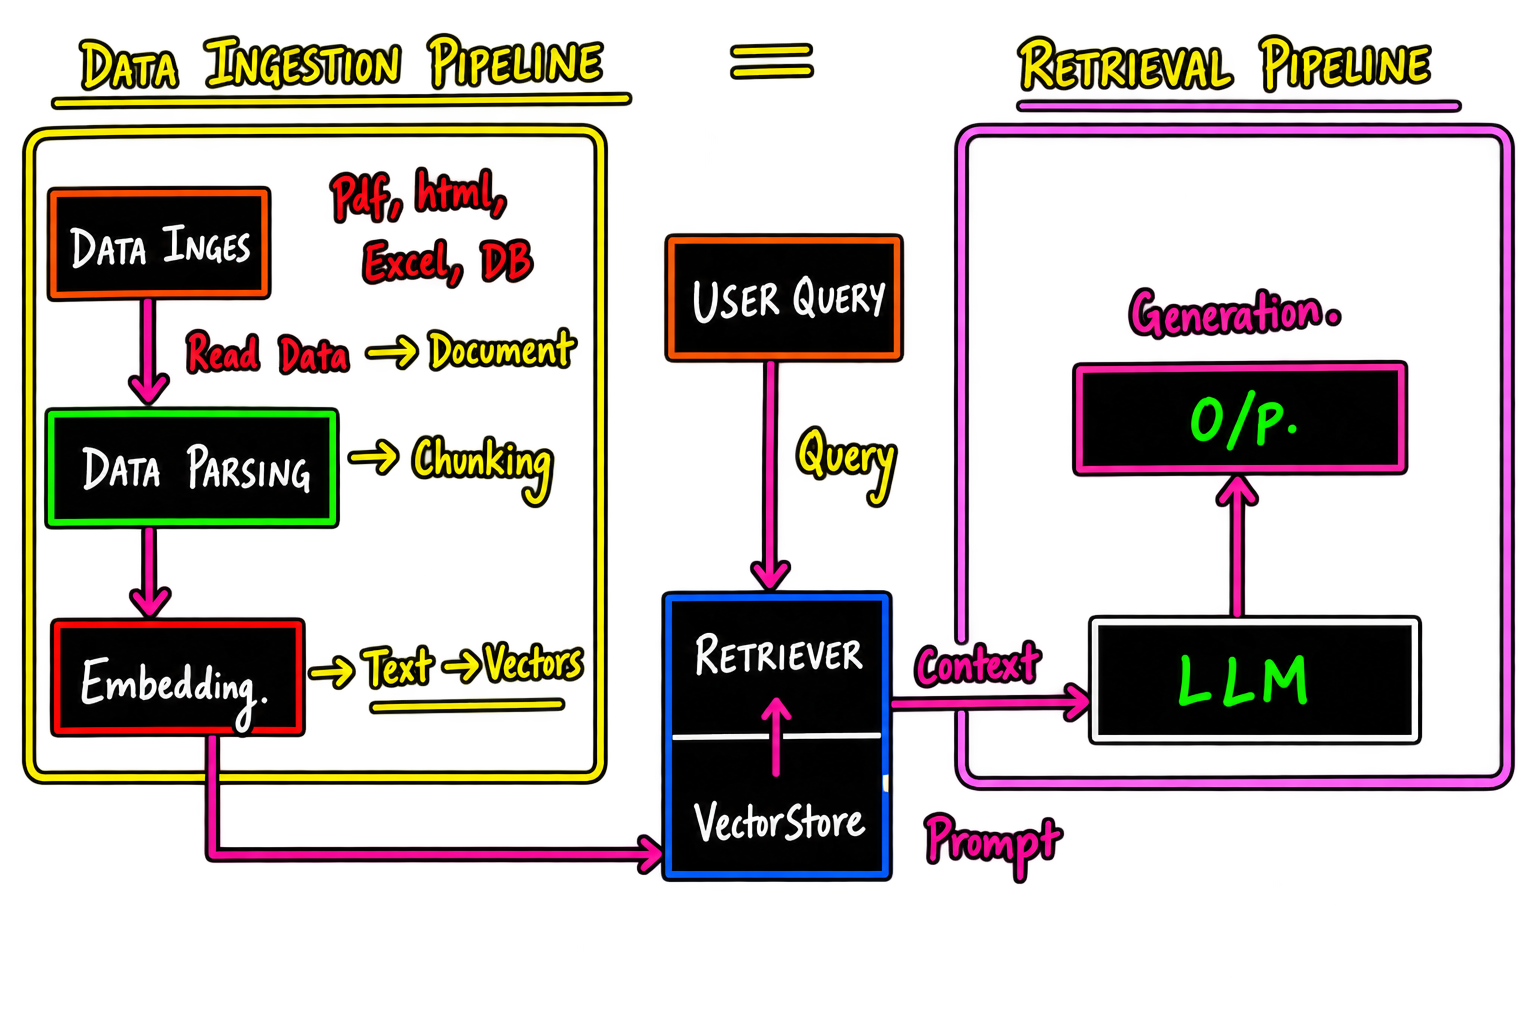

## RAG Pipeline - Data Ingestion to Vector DB Pipeline

## 1. DATA ingestion Pipeline

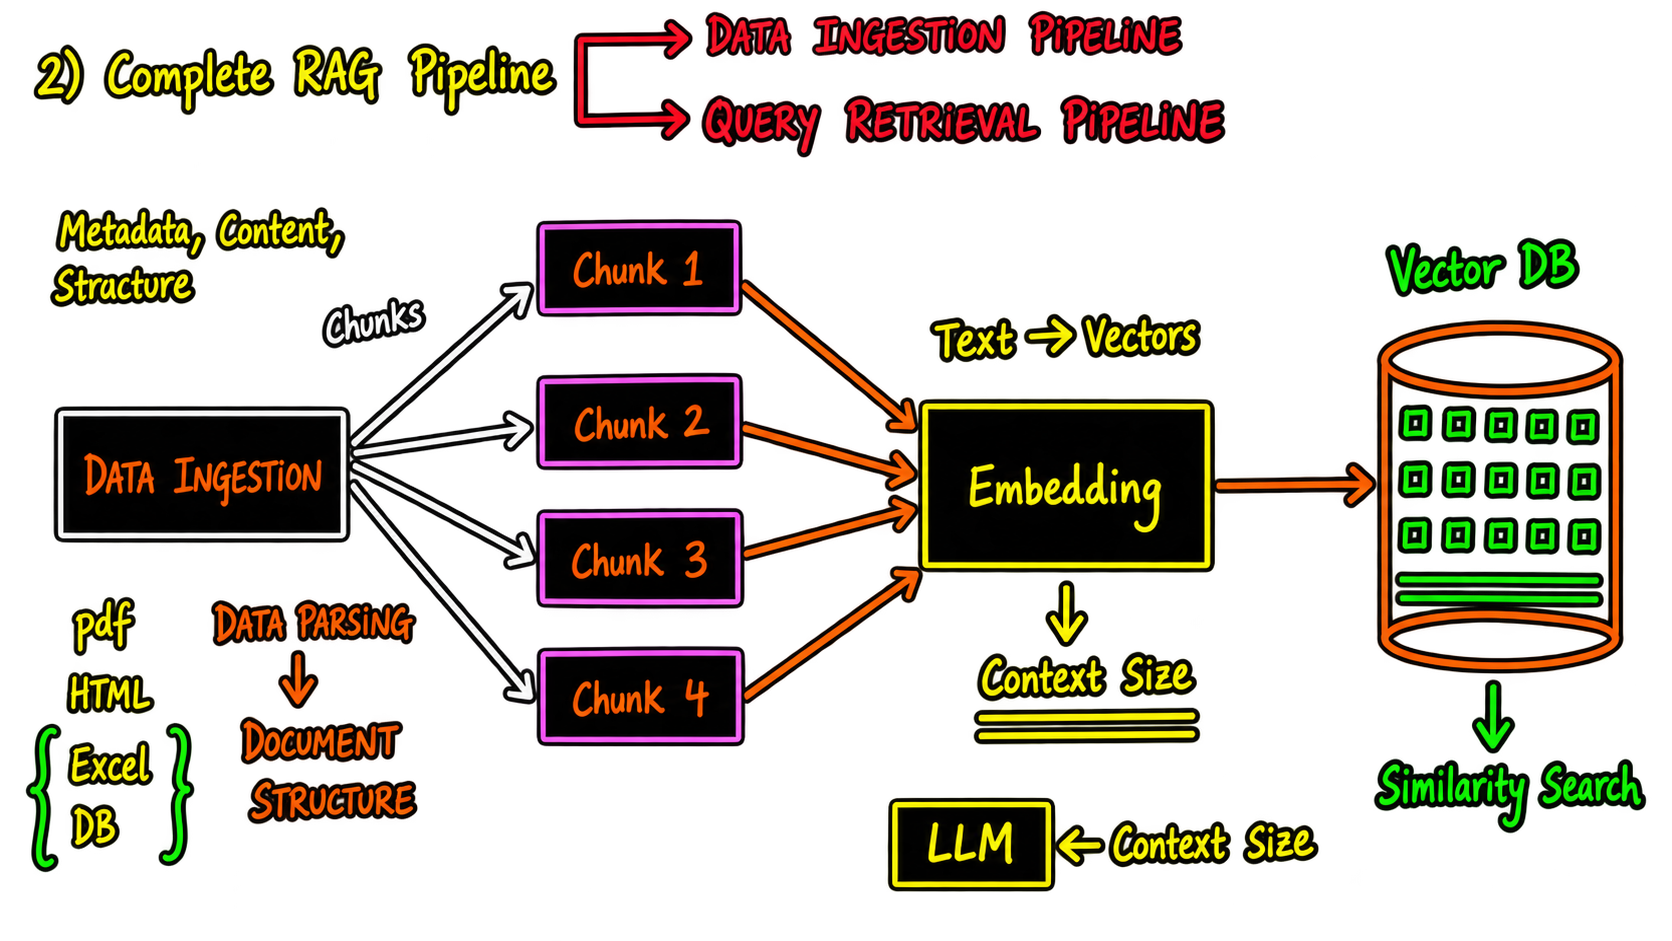

## 2. Query Retrieval Pipeline

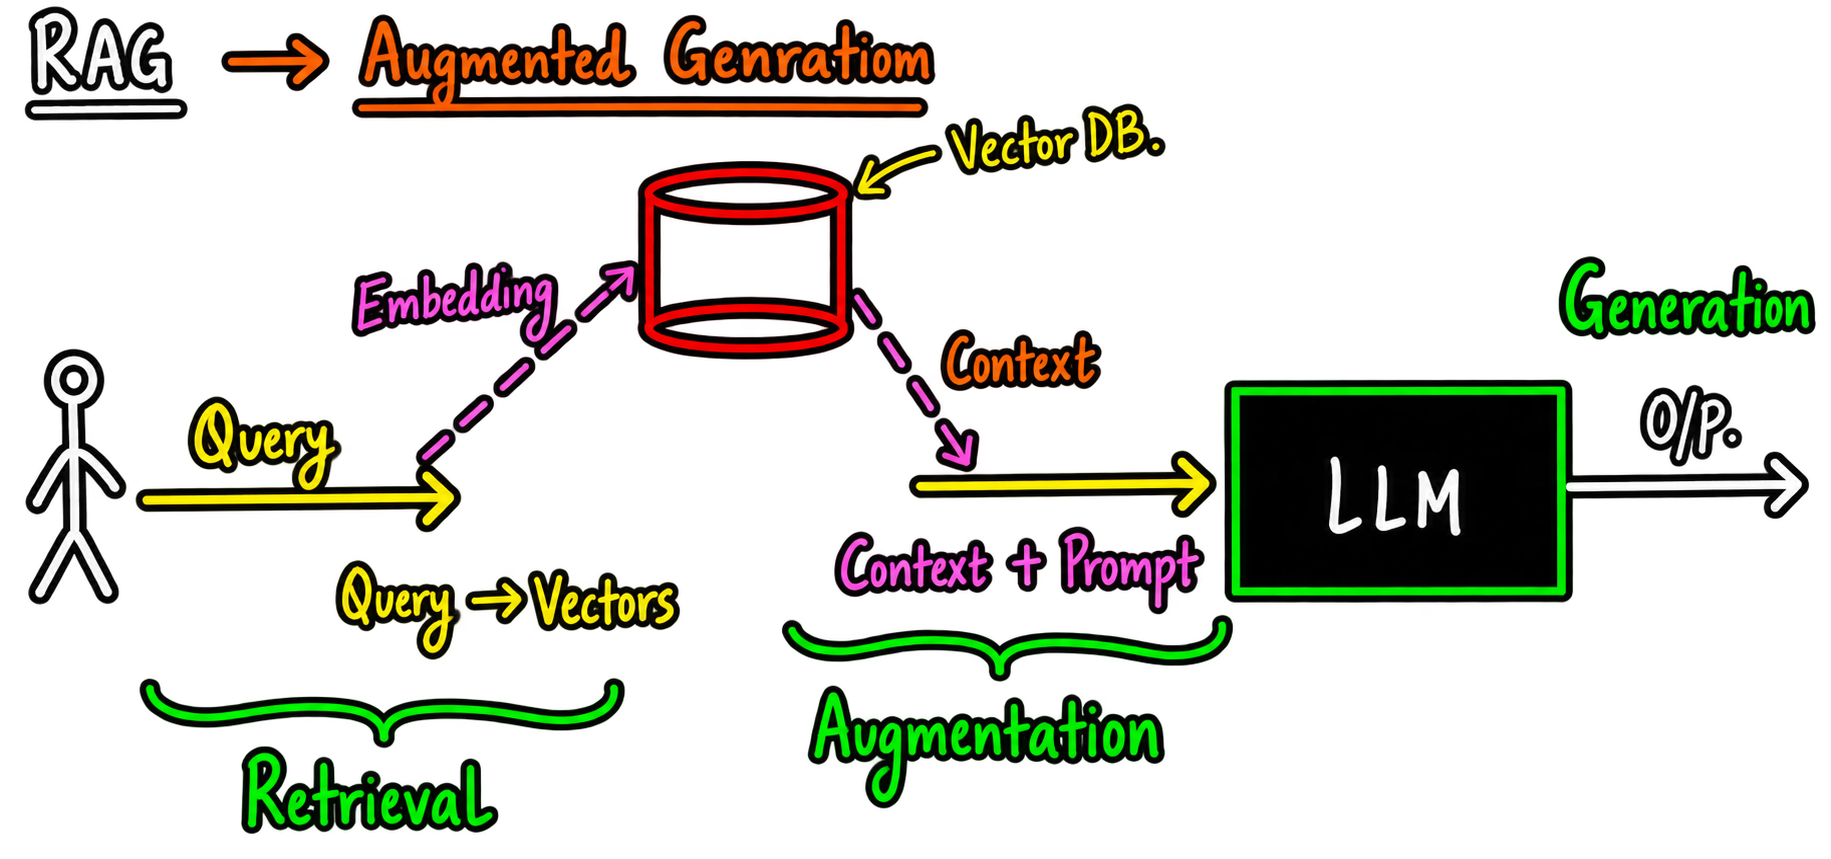

In [1]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23348\3933654057.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
d:\AI Dev\Generative AI\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Data Ingestion

In [2]:
## it reads the all the pdf files inside a folder
def process_all_pdfs(pdf_directory):
    '''Process all PDF files in a directory'''
    all_documents = []
    pdf_dir = Path(pdf_directory)

    #Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))

    print(f"Found {len(pdf_files)} PDF files to process")

    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()

            ## Adding source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'

            all_documents.extend(documents) #we will store all documents after reading into this list
            print(f"✅ Loaded {len(documents)} Pages")
        
        except Exception as e:
            print(f"❌ Error: {e}")
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

    # Process all PDF's in the directory
all_pdf_documents = process_all_pdfs("../data")

Found 6 PDF files to process

Processing: APIP(FINALVERSION).pdf
✅ Loaded 6 Pages

Processing: attention.pdf
✅ Loaded 1 Pages

Processing: embeddings.pdf
✅ Loaded 1 Pages

Processing: MALADE_Reseacrh_paper.pdf
✅ Loaded 49 Pages

Processing: objectdetection.pdf
✅ Loaded 1 Pages

Processing: proposal.pdf
✅ Loaded 1 Pages

Total documents loaded: 59


In [3]:
all_pdf_documents ## list of documents

[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}, page_content='FACULTY OF ENGINEERING AND TECHNOLOGY\nSCHOOL OF COMPUTATIONAL ENGINEERING\nDEPARTMENT OF AIML\n1\nAgentic PharmaCo Intelligent Platform(APIP)\nBatch Number: 11\nSAILESH CHIKKAM (TU6230105111007)\nJAYANTH. K (TU6230105111012)\nN. MOHAN SAI REDDY (TU6230105111027)                       \nSupervisor Name: DR.ANANDHI.M\nDesignation: ASP/CSE\nTime: 10:00 A.MDate: 20-08-2026\nPROJECT PHASE – I\nZeroth Review'),
 Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:

### 2. chunking  ---  Text splitting get into chunks

In [4]:
## Text splitting get into chunks

def split_documents(documents, chunk_size = 1000, chunk_overlap = 200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", "", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

    # show example of a chunk
    if split_docs:
        print(f"\nExample chunk: ")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")

    return split_docs

In [5]:
### here we should pass list of documents
chunks = split_documents(all_pdf_documents)
chunks

Split 59 documents into 248 chunks

Example chunk: 
Content: FACULTY OF ENGINEERING AND TECHNOLOGY
SCHOOL OF COMPUTATIONAL ENGINEERING
DEPARTMENT OF AIML
1
Agentic PharmaCo Intelligent Platform(APIP)
Batch Number: 11
SAILESH CHIKKAM (TU6230105111007)
JAYANTH. K...
Metadata: {'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}, page_content='FACULTY OF ENGINEERING AND TECHNOLOGY\nSCHOOL OF COMPUTATIONAL ENGINEERING\nDEPARTMENT OF AIML\n1\nAgentic PharmaCo Intelligent Platform(APIP)\nBatch Number: 11\nSAILESH CHIKKAM (TU6230105111007)\nJAYANTH. K (TU6230105111012)\nN. MOHAN SAI REDDY (TU6230105111027)                       \nSupervisor Name: DR.ANANDHI.M\nDesignation: ASP/CSE\nTime: 10:00 A.MDate: 20-08-2026\nPROJECT PHASE – I\nZeroth Review'),
 Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:

### 3. Embedding & VectorStoreDB

In [6]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
class EmbeddingManager:
    '''Handles document embedding generation using SentenceTransformer'''
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        '''
        Intialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        '''
        self.model_name = model_name
        self.model = None
        self._load_model() ##function loads "all_MiniLM-L6-v2"

    ## protected function _load_model()
    def _load_model(self):
        '''Load the SentenceTransformer model'''
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name) ## main
            print(f"Model loaded sunccefully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error in loading model {self.model_name}: {e}")
            raise

    ## to generate embeddings
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
            '''
            Generate embeddings for a list of texts

            Args:
            texts: List of text strings to embed

            Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
            '''
            if not self.model:
                raise ValueError("model not loaded")
            print(f"Generating Embeddings for {len(texts)} texts...")
            embeddings = self.model.encode(texts, show_progress_bar = True) ## main
            print(f"Generated embeddings with shape: {embeddings.shape}")
            return embeddings

## initialize the embedding manaager
embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2054.27it/s]


Model loaded sunccefully. Embedding dimension: 384


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23348\2172358583.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded sunccefully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


### 4. VectorStoreDB

In [8]:
class VectorStore:
    '''Manages document embeddings in aChromaDB vector store'''

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        '''
        Initialize the vector store
        
        Args:
        collection_name: Name of the ChromaDB collection
        persist_directory: Directory to persists the vector store
        '''

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

        ##ChromaDB
    def _initialize_store(self):
        '''Initialize ChromaDB client and collection'''
        try:
            #Create Persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path = self.persist_directory)

            # Get or create collection
            ## where we are gng to store the vectors after embedding in vector store
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )

            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing Documents in collection: {self.collection.count}")
        except Exception as e:
            print(f"Error in initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        '''
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of Langchain documents
            embeddings: Corresponding embeddings for the documents
        '''
        if len(documents) != len(embeddings):
            raise ValueError("Number of Documents must match number os=f embeddings")
        print(f"Adding {len(documents)} documents to vector store...")

        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)

            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)

            # Document content
            documents_text.append(doc.page_content)

            # Embedding
            embeddings_list.append(embedding.tolist())
        try:
            self.collection.add(
                ids=ids,
                embeddings = embeddings_list,
                metadatas = metadatas,
                documents = documents_text
            )
            print(f"Successfully added  {len(documents)} documents to vector store")
            print(f"Total documnets in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise
        
vectorstore = VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing Documents in collection: <bound method Collection.count of Collection(name=pdf_documents)>


In [9]:
chunks

[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}, page_content='FACULTY OF ENGINEERING AND TECHNOLOGY\nSCHOOL OF COMPUTATIONAL ENGINEERING\nDEPARTMENT OF AIML\n1\nAgentic PharmaCo Intelligent Platform(APIP)\nBatch Number: 11\nSAILESH CHIKKAM (TU6230105111007)\nJAYANTH. K (TU6230105111012)\nN. MOHAN SAI REDDY (TU6230105111027)                       \nSupervisor Name: DR.ANANDHI.M\nDesignation: ASP/CSE\nTime: 10:00 A.MDate: 20-08-2026\nPROJECT PHASE – I\nZeroth Review'),
 Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:

## Let's Extract all text from the chunks and generate an embedding

In [10]:
## Convert the text to embeddings
texts = [doc.page_content for doc in chunks]
texts

## Generate the Embeddings
embeddings = embedding_manager.generate_embeddings(texts)

## store in the vector database
vectorstore.add_documents(chunks, embeddings)

Generating Embeddings for 248 texts...


Batches: 100%|██████████| 8/8 [00:15<00:00,  1.94s/it]


Generated embeddings with shape: (248, 384)
Adding 248 documents to vector store...
Successfully added  248 documents to vector store
Total documnets in collection: 761


### Here the User Query, we should convert that user query to embedding and that is given to retriever with VectorStore then to LLM

## RAG Retriever Pipeline From VectorStore

#### Retriever built on top of VectorStore

In [11]:
class RAGRetriever:
    '''Handles query-based retrieval from the vector store'''

    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        '''
        Intialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embeddings_manager: Manager for generating query embeddings
        '''

        self.vector_store = vector_store ## 2 class variables
        self.embedding_manager = embedding_manager

    ### retriever function main functionality is use to retrieve based on specific query
    ### this function helps us to get the context in  RAG Pipeline
    def retrieve(self, query: str, top_k = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        '''Retrieve relevant documents for a query
        
        Args:
            query: The search  query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        '''

        print(f"Retrieve documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")

        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]

        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings = [query_embedding.tolist()], # giving inform of a list
                n_results = top_k
            )

            # Process results
            retrieved_docs = []

            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]

                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):

                    # Convert distance to similarity score (ChromaDB uses coine distance(cosine similarity))
                    similarity_score = 1 - distance

                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id' : doc_id,
                            'content' : document,
                            'metadata' : metadata,
                            'similarity_score' : similarity_score,
                            'distance' : distance,
                            'rank' : i+1
                        })
                print(f"Retrieved {len(retrieved_docs)} documents (sfter filtering)")
            else:
                print("No documents found")

            return retrieved_docs

        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever = RAGRetriever(vectorstore, embedding_manager)

In [12]:
rag_retriever

In [13]:
rag_retriever.retrieve("What is MALADE effectively identifies ADEs")
# result is your context

Retrieve documents for query: 'What is MALADE effectively identifies ADEs'
Top K: 5, Score threshold: 0.0
Generating Embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 20.75it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (sfter filtering)


[{'id': 'doc_e59863e3_38',
  'content': '0.85 with GPT-4 Turbo, and 0.90 with GPT-4o (Section 5). To the best of our knowledge, this is\nthe best performance among the baselines, even though the direct comparison may be limited 3.\nGrounded generation of responses and justifications. The design of MALADE offers key\nfeatures essential for high-stakes applications like ADE identification: (1) A structured format for\ndrug-to-outcome associations, including scores indicating the strength of the association and rarity\nof the adverse event; this is important to ensure robust downstream processing of the extracted\nassociations. (2) Justifications for the extracted drug-outcome associations, allowing human ex-\nperts to understand and validate the associations. This is possible due to the RAG component\nof the MALADE architecture, which allows leveraging various external sources such as medical\nliterature, drug labels, FDA tools (e.g., OpenFDA drug information API), as well as common clin

# ======= Data Ingestion Pipeline is Completed=======

## Now Query Retrieval Pipeline + LLM

## Integrating VectorDB Context Pipeline with LLM output

In [ ]:
##Simple RAG pipeline with GROQ LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv() # loading entire variables

groq_api_key = os.getenv("GROQ_API_KEY")

llm_model = ChatGroq(
    api_key=groq_api_key,
    model="groq/compound-mini",
    temperature=0
)

### Intialize the Groq LLM (set your GROQ_API_KEY)
groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(groq_api_key = groq_api_key, model_name=llm_model, temperature = 0.1, max_tokens=1024)

## 2. Simple RAG function: retrieve context + generate response

def rag_simple(query,retriever,llm,top_k = 3):
    ## retrieve the context
    results = retriever.retrieve(query,top_k=top_k)
    context = "\n\n".join([doc['content'] for doc in results]) if results else""
    if not context:
        return "Norelevant context found to answer the question"

    ## generate the answer using t=GROQ LLM
    prompt=f'''Use the following context to answer the question concisely.
        Context: {context}
        
        Question: {query}
        
        Answer:'''

    response=llm.invoke([prompt.format(context=context,query=query)])
    return response.content

In [35]:
answer = rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)

Retrieve documents for query: 'What is attention mechanism?'
Top K: 3, Score threshold: 0.0
Generating Embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 50.01it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (sfter filtering)


The attention mechanism lets a model dynamically weigh the relevance of different tokens when forming a representation for a given token or output, by computing similarities between learned query, key, and value vectors and using these weights to combine the values.


## Let's Enhance RAG Pipeline Features
#### Enhanced RAG Pipeline

In [ ]:
## ---- Enhanced RAG pipeline Features -----
def rag_advanced(query, retriever, llm, top_k=5, min_score = 0.2, return_context = False):
    '''
    RAG Pipeline with extra features:
    - Return answer, sources, confidence score, and optionally full context.
    '''
    results = retriever.retrieve(query, top_k=top_k, score_threshold = min_score)
    if not results:
        return {'answer': 'No relevant content found.','sources':[],'confidence':0.0,'context': ''}

    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source' : doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page','unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    }for doc in results]

    confidence = max([doc['similarity_score'] for doc in results])

    # Generate answer
    prompt = f'''Use the following content to answer the question concisely.\nContent:\n{context}\n\nQuestion: {query}\n\nAnswer: '''
    response = llm.invoke([prompt.format(context = context, query = query)])

    output = {
        'answer' : response.content,
        'sources' : sources,
        'confidence' : confidence
    }
    if return_context:
        output['context'] = context
    return output

result = rag_advanced("What is the role of YOLO in Object Detection ?",rag_retriever, llm, top_k=3,min_score=0.1,return_context=True)
print("Answer: ", result['answer'])
print()
print("Sources: ", result['sources'])
print("Confidence: ", result['confidence'])
print("Context Preview: ", result['context'][:300])

Retrieve documents for query: 'What is the role of YOLO in Object Detection ?'
Top K: 3, Score threshold: 0.1
Generating Embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 51.36it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (sfter filtering)


Answer:  YOLO is a **one‑stage object‑detection architecture** that skips a separate proposal step. It directly predicts bounding‑box coordinates and class probabilities from the input image in a single forward pass, emphasizing high speed and real‑time performance.

Sources:  [{'source': 'objectdetection.pdf', 'page': 0, 'score': 0.10120218992233276, 'preview': 'Object Detection\nA concise computer-vision reference\n1. Overview\nObject detection identifies instances of objects in an image and predicts a bounding box and class label\nfor each detected instance.\n2. Main Stages\nA typical detector extracts visual features, predicts candidate object locations and cl...'}, {'source': 'objectdetection.pdf', 'page': 0, 'score': 0.10120218992233276, 'preview': 'Object Detection\nA concise computer-vision reference\n1. Overview\nObject detection identifies instances of objects in an image and predicts a bounding box and class label\nfor each detected instance.\n2. Main Stages\nA typical detec

### Advnaced RAG Pipeline

In [53]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = [] # Store query history

    def query(self, question: str, top_k: int = 5, min_score = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:

        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]

            # Streaming answer simulation
            prompt = f'''Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:'''
            if stream:
                print("Streaming answer: ")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end = '', flush = True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer (citation is nothing but source document references)
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentence : \n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is the role of YOLO in Object Detection ?", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieve documents for query: 'what is the role of YOLO in Object Detection ?'
Top K: 3, Score threshold: 0.1
Generating Embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 41.66it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (sfter filtering)
Streaming answer: 
Use the following context to answer the question concisely.
Context:
Object Detection
A concise computer-vision reference
1. Overview
Object detection identifies instances of objects in an image and predicts a bounding box and class label
for each detected instance.
2. Main Stages
A typical detector extracts visual fea

tures, predicts candidate object locations and class probabilities, and
filters overlapping detections using confidence thresholds and non-maximum suppression.
3. Common Architectures
One-stage detectors such as YOLO prioritize speed, while two-stage detectors such as Faster R-CNN
use a proposal stage followed by refined classification and localization.
4. Evaluation
Intersection over Union (IoU) measures overlap between predicted and ground-truth boxes. Precision,
recall, Average Precision (AP), and mean Average Precision (mAP) are common evaluation metrics.
5. Applications
Applications include surveillance, autonomous systems, industrial inspection, retail analytics,
medical-image analysis, and traffic monitoring.
Metric
Meaning
IoU

Object Detection
A concise computer-vision reference
1. Overview
Object detection identifies instances of objects in an image and predicts a bounding box and class label
for each detected instance.
2. Main Stages
A typical detector extracts visual featur